# 🔢 Notebook 3 — Gemini Embeddings + Qdrant Indexing

هذا الـ notebook يغطي:
1. الاتصال بـ Qdrant المحلي والتحقق من صحته
2. توليد embeddings بـ Gemini (`text-embedding-004`)
3. الفرق بين `RETRIEVAL_DOCUMENT` و `RETRIEVAL_QUERY`
4. فهرسة دفعة صغيرة (small batch) للاختبار
5. التحقق من بيانات الـ collection
6. Ingestion كامل (اختياري)

> ⚠️ **قبل تشغيل هذا الـ notebook:**
> 1. `docker compose up -d` (Qdrant شغّال)
> 2. ملف `.env` فيه `GEMINI_API_KEY`
---

In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
from app.config import get_settings

settings = get_settings()
print('Gemini model  :', settings.gemini_generation_model)
print('Embed  model  :', settings.embedding_model)
print('Qdrant URL    :', settings.qdrant_url)
print('Collection    :', settings.qdrant_collection)
print('Gemini key OK :', settings.gemini_configured)
print('Qdrant OK     :', settings.qdrant_configured)

Gemini model  : gemini-2.5-flash
Embed  model  : intfloat/multilingual-e5-large
Qdrant URL    : http://localhost:6333
Collection    : natural_questions
Gemini key OK : True
Qdrant OK     : True


## 1. الاتصال بـ Qdrant والتحقق من صحته

In [2]:
from qdrant_client import QdrantClient

client = QdrantClient(url=settings.qdrant_url,
                      api_key=settings.qdrant_api_key or None,
                      timeout=30)

# Healthcheck
info = client.get_collections()
print('✅ Qdrant متصل بنجاح!')
print(f'Collections الموجودة: {[c.name for c in info.collections]}')

✅ Qdrant متصل بنجاح!
Collections الموجودة: []


c:\Users\EXPRESS\Anaconda3\envs\QA\Lib\site-packages\qdrant_client\qdrant_remote.py:282: UserWarning: Qdrant client version 1.18.0 is incompatible with server version 1.13.2. Major versions should match and minor version difference must not exceed 1. Set check_compatibility=False to skip version check.
  show_warning(


In [3]:
# معلومات أكثر عن collection لو موجودة
col_name = settings.qdrant_collection
if client.collection_exists(col_name):
    info = client.get_collection(col_name)
    print(f'Collection: {col_name}')
    print(f'Points count: {info.points_count:,}')
    print(f'Vectors size: {info.config.params.vectors.size}')
    print(f'Distance    : {info.config.params.vectors.distance}')
else:
    print(f'⚠️ Collection "{col_name}" غير موجودة — ستُنشأ في الـ cells التالية')

⚠️ Collection "natural_questions" غير موجودة — ستُنشأ في الـ cells التالية


---
## 2. Gemini Embeddings — توليد vectors

In [5]:
from app.rag.embeddings import E5Embedder

embedder = E5Embedder(settings)
print(f'Embedding model: {embedder._model}')
print(f'Batch size     : {embedder._batch_size}')
print(f'Dimension      : {embedder.dimension}')  # probe call
print(f'Embedding model: {embedder._model}')


Embedding model: None
Batch size     : 32


Loading weights: 100%|██████████| 391/391 [00:00<00:00, 2785.19it/s]


Dimension      : 1024
Embedding model: SentenceTransformer(
  (0): Transformer({'transformer_task': 'feature-extraction', 'modality_config': {'text': {'method': 'forward', 'method_output_name': 'last_hidden_state'}}, 'module_output_name': 'token_embeddings', 'architecture': 'XLMRobertaModel'})
  (1): Pooling({'embedding_dimension': 1024, 'pooling_mode': 'mean', 'include_prompt': True})
  (2): Normalize({})
)


In [6]:
# تضمين نص واحد وفحص الـ vector
test_text = "Who had the most wins in the NFL?"
vec = embedder.embed_query(test_text)

print(f'Text  : {test_text}')
print(f'Vector dimensions : {len(vec)}')
print(f'First 10 values   : {[round(v,4) for v in vec[:10]]}')
print(f'Vector norm       : {sum(v**2 for v in vec)**0.5:.4f}')  # ~1.0 لأنه normalized
print(f'Min / Max         : {min(vec):.4f} / {max(vec):.4f}')

Text  : Who had the most wins in the NFL?
Vector dimensions : 1024
First 10 values   : [0.0145, -0.0127, -0.0399, -0.025, 0.0339, -0.0266, -0.0277, 0.0118, 0.0345, -0.0259]
Vector norm       : 1.0000
Min / Max         : -0.0826 / 0.1957


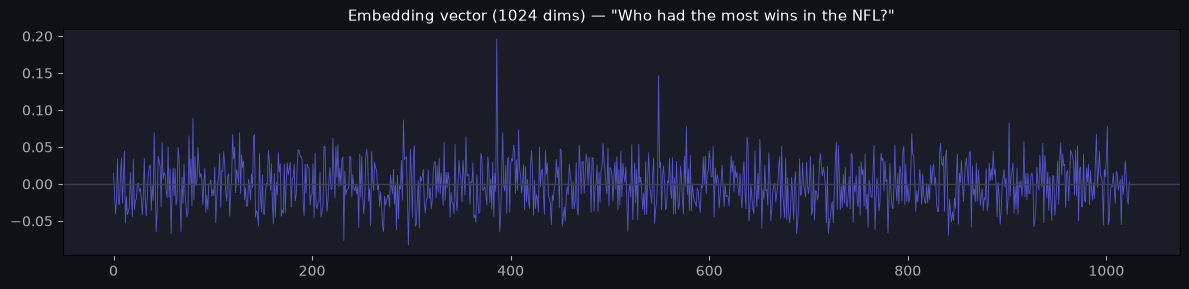

In [7]:
# رسم توزيع قيم الـ vector
fig, ax = plt.subplots(figsize=(12, 3), facecolor='#0f1117')
ax.set_facecolor('#1a1d27')
ax.plot(vec, color='#6366f1', lw=0.6, alpha=0.8)
ax.axhline(0, color='#3a3f55', lw=1)
ax.set_title(f'Embedding vector ({len(vec)} dims) — "{test_text}"',
             color='white', fontsize=11)
ax.tick_params(colors='#b0b0b0')
plt.tight_layout(); plt.show()

---
## 3. الفرق بين RETRIEVAL_DOCUMENT و RETRIEVAL_QUERY

In [8]:
import numpy as np

question  = "Who had the most NFL wins?"
answer    = "Tom Brady holds the record for most wins with 220."
unrelated = "The Amazon rainforest is the world's largest tropical rainforest."

q_vec  = embedder.embed([question],  task_type='RETRIEVAL_QUERY')[0]
a_vec  = embedder.embed([answer],    task_type='RETRIEVAL_DOCUMENT')[0]
u_vec  = embedder.embed([unrelated], task_type='RETRIEVAL_DOCUMENT')[0]

def cosine(a, b):
    a, b = np.array(a), np.array(b)
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))

sim_rel   = cosine(q_vec, a_vec)
sim_unrel = cosine(q_vec, u_vec)

print(f'سؤال  : {question}')
print(f'إجابة ذات صلة : {answer}')
print(f'إجابة غير ذات صلة : {unrelated[:50]}')
print()
print(f'Cosine similarity (سؤال ↔ ذات صلة)     : {sim_rel:.4f}')
print(f'Cosine similarity (سؤال ↔ غير ذات صلة) : {sim_unrel:.4f}')
print(f'\n✅ النموذج يميّز بفارق: {sim_rel - sim_unrel:.4f}')

سؤال  : Who had the most NFL wins?
إجابة ذات صلة : Tom Brady holds the record for most wins with 220.
إجابة غير ذات صلة : The Amazon rainforest is the world's largest tropi

Cosine similarity (سؤال ↔ ذات صلة)     : 0.8379
Cosine similarity (سؤال ↔ غير ذات صلة) : 0.6981

✅ النموذج يميّز بفارق: 0.1397


In [9]:
# فرق استخدام QUERY vs DOCUMENT لنفس النص
text = "Tom Brady NFL wins record"
as_query = embedder.embed([text], task_type='RETRIEVAL_QUERY')[0]
as_doc   = embedder.embed([text], task_type='RETRIEVAL_DOCUMENT')[0]

sim_self = cosine(as_query, as_doc)
print(f'نفس النص مرة كـ QUERY ومرة كـ DOCUMENT:')
print(f'Cosine similarity = {sim_self:.4f}')
print('(لو 1.0 → نفس الـ vector؛ لو أقل → النموذج يعاملهم مختلف)')

نفس النص مرة كـ QUERY ومرة كـ DOCUMENT:
Cosine similarity = 0.8798
(لو 1.0 → نفس الـ vector؛ لو أقل → النموذج يعاملهم مختلف)


---
## 4. فهرسة دفعة صغيرة — Small Batch Test

In [10]:
from app.rag.preprocessing import build_documents
from app.rag.vector_store import QdrantVectorStore

CSV_PATH = str(settings.resolve(settings.dataset_path))

# بنى 20 مستند فقط كـ test
TEST_ROWS = 20
docs = build_documents(CSV_PATH, max_rows=TEST_ROWS,
                       chunk_size=settings.chunk_size,
                       chunk_overlap=settings.chunk_overlap)
print(f'Docs built: {len(docs)} chunks from {TEST_ROWS} rows')
print(f'Example text: {docs[0].text[:150]}...')

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (631 > 512). Running this sequence through the model will result in indexing errors


Docs built: 21 chunks from 20 rows
Example text: Question: which is the most common use of opt-in e-mail marketing
Answer: A common example of permission marketing is a newsletter sent to an advertis...


In [11]:
# تضمين الـ texts
texts = [d.text for d in docs]
print(f'تضمين {len(texts)} نص...')
vectors = embedder.embed_documents(texts)
print(f'✅ تم! كل vector طوله {len(vectors[0])} بُعد')
print(f'Shape: {len(vectors)} × {len(vectors[0])}')

تضمين 21 نص...
✅ تم! كل vector طوله 1024 بُعد
Shape: 21 × 1024


In [12]:
# إنشاء collection ورفع البيانات
TEST_COLLECTION = 'rag_test_notebook'

# استخدام collection منفصلة للتجربة
from qdrant_client import models as qmodels

if client.collection_exists(TEST_COLLECTION):
    client.delete_collection(TEST_COLLECTION)
    print(f'Deleted old test collection.')

client.create_collection(
    collection_name=TEST_COLLECTION,
    vectors_config=qmodels.VectorParams(size=embedder.dimension,
                                         distance=qmodels.Distance.COSINE)
)
print(f'✅ Collection "{TEST_COLLECTION}" أُنشئت')

# Upsert
import uuid
points = [
    qmodels.PointStruct(
        id=str(uuid.uuid5(uuid.NAMESPACE_URL, doc.id)),
        vector=vectors[i],
        payload=doc.to_payload()
    )
    for i, doc in enumerate(docs)
]
client.upsert(collection_name=TEST_COLLECTION, points=points)
count = client.count(TEST_COLLECTION, exact=True).count
print(f'✅ Upserted {count} points')

✅ Collection "rag_test_notebook" أُنشئت
✅ Upserted 21 points


---
## 5. اختبار البحث في الـ collection

In [13]:
# جرّب سؤال من عندك
MY_QUERY = "What is the most common use of email marketing?"

q_vec = embedder.embed_query(MY_QUERY)
results = client.query_points(
    collection_name=TEST_COLLECTION,
    query=q_vec,
    limit=3,
    with_payload=True
)

print(f'السؤال: {MY_QUERY}\n')
print('═' * 70)
for i, hit in enumerate(results.points, 1):
    print(f'\n[{i}] Score: {hit.score:.4f}')
    print(f'    Question : {hit.payload.get("question","")[:70]}')
    print(f'    Domain   : {hit.payload.get("domain","")} | '
          f'Difficulty: {hit.payload.get("difficulty","")} | '
          f'Type: {hit.payload.get("question_type","")}')
    print(f'    Answer   : {hit.payload.get("long_answer",hit.payload.get("text",""))[:120]}...')

السؤال: What is the most common use of email marketing?

══════════════════════════════════════════════════════════════════════

[1] Score: 0.8548
    Question : which is the most common use of opt-in e-mail marketing
    Domain   : technology | Difficulty: medium | Type: boolean
    Answer   : A common example of permission marketing is a newsletter sent to an advertising firm's customers. Such newsletters infor...

[2] Score: 0.7057
    Question : who's the director of the price is right
    Domain   : entertainment | Difficulty: medium | Type: boolean
    Answer   : The game show production team of Mark Goodson and Bill Tod man was responsible for producing the original as well as the...

[3] Score: 0.6965
    Question : who's the director of the price is right
    Domain   : entertainment | Difficulty: medium | Type: boolean
    Answer   : The game show production team of Mark Goodson and Bill Tod man was responsible for producing the original as well as the...


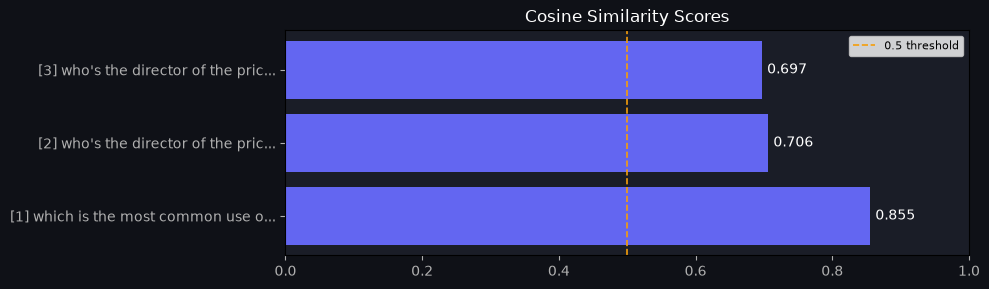

In [14]:
# رسم scores للنتائج
scores = [h.score for h in results.points]
labels = [f'[{i+1}] {h.payload.get("question","")[:30]}...' for i, h in enumerate(results.points)]

fig, ax = plt.subplots(figsize=(10, 3), facecolor='#0f1117')
ax.set_facecolor('#1a1d27')
bars = ax.barh(labels, scores, color='#6366f1', edgecolor='none')
ax.bar_label(bars, fmt='%.3f', color='white', fontsize=10, padding=4)
ax.set_xlim(0, 1)
ax.set_title('Cosine Similarity Scores', color='white')
ax.tick_params(colors='#b0b0b0')
ax.axvline(0.5, color='#f59e0b', lw=1.2, linestyle='--', label='0.5 threshold')
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

---
## 6. Full Ingestion (اختياري — يُشغَّل مرة واحدة)

In [16]:
# ⚠️ هذه الـ cell تُشغّل الفهرسة الكاملة — قد تستغرق دقائق
# غيّر RUN_FULL_INGEST = True لتشغيلها

RUN_FULL_INGEST = True   # ← غيّر لـ True لتشغيل الفهرسة الكاملة

if RUN_FULL_INGEST:
    import time
    from app.rag.vector_store import QdrantVectorStore

    print(f'Building documents (max {settings.max_ingest_rows} rows)...')
    all_docs = build_documents(CSV_PATH,
                               max_rows=settings.max_ingest_rows,
                               chunk_size=settings.chunk_size,
                               chunk_overlap=settings.chunk_overlap)
    print(f'Docs: {len(all_docs)}')

    store = QdrantVectorStore(settings, dimension=embedder.dimension)
    store.ensure_collection(dimension=embedder.dimension, recreate=True)

    t0 = time.perf_counter()
    all_texts = [d.text for d in all_docs]
    all_vecs  = embedder.embed_documents(all_texts)
    upserted  = store.upsert(all_docs, all_vecs)
    elapsed   = time.perf_counter() - t0

    print(f'✅ Upserted {upserted} points in {elapsed:.1f}s')
    print(f'Collection now holds {store.count()} points')
else:
    print('Full ingestion skipped. شغّل scripts/ingest.py أو اجعل RUN_FULL_INGEST=True')

Building documents (max 2000 rows)...
Docs: 2040


c:\Users\EXPRESS\Anaconda3\envs\QA\Lib\site-packages\qdrant_client\qdrant_remote.py:282: UserWarning: Qdrant client version 1.18.0 is incompatible with server version 1.13.2. Major versions should match and minor version difference must not exceed 1. Set check_compatibility=False to skip version check.
  show_warning(


✅ Upserted 2040 points in 1825.8s
Collection now holds 2040 points


In [ ]:
# تنظيف الـ collection التجريبية
CLEANUP = True   # ← False لو عايز تحتفظ بالـ test collection
if CLEANUP and client.collection_exists(TEST_COLLECTION):
    client.delete_collection(TEST_COLLECTION)
    print(f'Deleted test collection "{TEST_COLLECTION}"')